# Ice Cream Sales — Data Cleaning, Covariance/Correlation, and Linearity Check

## 1. Load & Inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("Icecream_Sales_wr_Rain_and_Temperature.csv")
df.head(10)


,Temperature (F),Ice-cream Price ($),Number of Tourists (thousands),"Ice Cream Sales ($,thousands)",Did it rain on that day?
0,80.6,1.00,89.5,90,No
1,75.2,1.00,86.4,85,No
2,86.0,2.00,99.2,107,No
3,75.2,2.00,72.4,71,Yes
4,60.8,2.00,71.2,65,Yes
5,68.0,2.00,71.0,69,Yes
6,71.6,1.25,78.0,67,Yes
7,66.2,1.50,74.3,70,Yes
8,60.8,1.50,69.4,65,Yes
9,78.8,1.50,82.5,81,Yes


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (F)                 20 non-null     float64
 1   Ice-cream Price ($)             20 non-null     float64
 2   Number of Tourists (thousands)  20 non-null     float64
 3   Ice Cream Sales ($,thousands)   20 non-null     int64  
 4   Did it rain on that day?        20 non-null     str    
dtypes: float64(3), int64(1), str(1)
memory usage: 932.0 bytes


## 2. Cleaning Checks

In [3]:
print("Shape:", df.shape)
print("\nNull values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (20, 5)

Null values per column:
Temperature (F)                   0
Ice-cream Price ($)               0
Number of Tourists (thousands)    0
Ice Cream Sales ($,thousands)     0
Did it rain on that day?          0
dtype: int64

Duplicate rows: 0


In [4]:
# Sanity check numeric ranges - look for anything impossible (negative sales/price/temp, etc.)
df.describe()


,Temperature (F),Ice-cream Price ($),Number of Tourists (thousands),"Ice Cream Sales ($,thousands)"
count,20.000000,20.000000,20.000000,20.000000
mean,73.130000,1.362500,78.955000,76.850000
std,7.598137,0.496534,10.992556,13.259654
min,60.800000,0.750000,52.100000,53.000000
25%,67.550000,1.000000,71.175000,66.750000
50%,75.200000,1.375000,76.600000,74.000000
75%,78.800000,2.000000,88.025000,85.750000
max,86.000000,2.000000,99.200000,107.000000


**Result:** No nulls, no duplicates, and all values fall in sensible ranges (temperatures 60-86°F, prices $0.75-$2.00, sales $53k-$107k). This dataset is already clean — only 20 rows, so it's worth double-checking manually too.

## 3. Rename columns for easier handling (optional, keeps original meaning)

In [5]:
df.columns = ["Temperature", "Price", "Tourists", "Sales", "Rain"]
df.head()


,Temperature,Price,Tourists,Sales,Rain
0,80.6,1.0,89.5,90,No
1,75.2,1.0,86.4,85,No
2,86.0,2.0,99.2,107,No
3,75.2,2.0,72.4,71,Yes
4,60.8,2.0,71.2,65,Yes


## 4. Covariance Matrix

In [6]:
numeric_df = df.select_dtypes(include="number")
cov_matrix = numeric_df.cov()
cov_matrix


,Temperature,Price,Tourists,Sales
Temperature,57.731684,0.150395,65.071421,86.925789
Price,0.150395,0.246546,0.246118,0.623026
Tourists,65.071421,0.246118,120.836289,136.050789
Sales,86.925789,0.623026,136.050789,175.818421


## 5. Correlation Matrix

In [7]:
corr_matrix = numeric_df.corr()
corr_matrix


,Temperature,Price,Tourists,Sales
Temperature,1.000000,0.039864,0.779084,0.862798
Price,0.039864,1.000000,0.045092,0.094629
Tourists,0.779084,0.045092,1.000000,0.933405
Sales,0.862798,0.094629,0.933405,1.000000


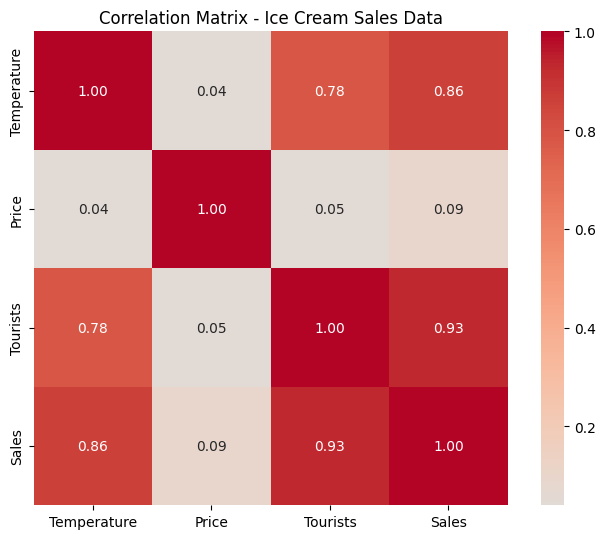

In [8]:
plt.figure(figsize=(7,5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix - Ice Cream Sales Data")
plt.tight_layout()
plt.show()


In [9]:
# Which variables correlate most strongly with Sales?
corr_matrix["Sales"].sort_values(ascending=False)


Sales          1.000000
Tourists       0.933405
Temperature    0.862798
Price          0.094629
Name: Sales, dtype: float64

## 6. Scatterplots: Checking Linearity

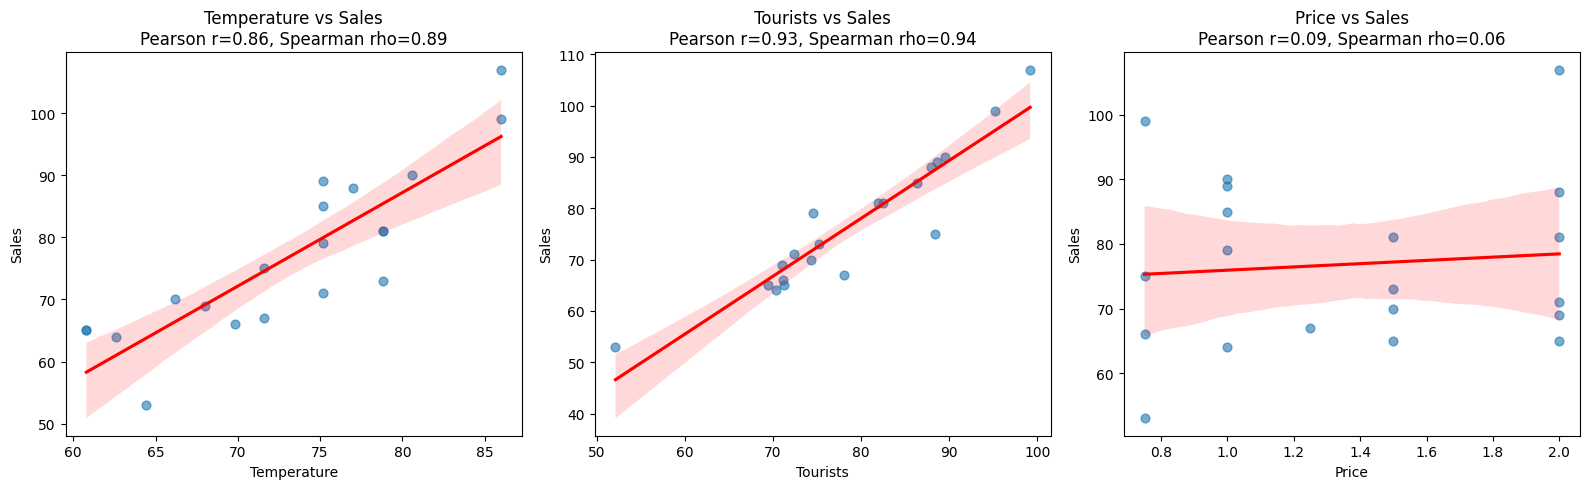

In [10]:
pairs = [("Temperature","Sales"), ("Tourists","Sales"), ("Price","Sales")]

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, (x, y) in zip(axes, pairs):
    sns.regplot(x=x, y=y, data=df, ax=ax, scatter_kws={"alpha":0.6,"s":40}, line_kws={"color":"red"})
    r, p = stats.pearsonr(df[x], df[y])
    rho, ps = stats.spearmanr(df[x], df[y])
    ax.set_title(f"{x} vs {y}\nPearson r={r:.2f}, Spearman rho={rho:.2f}")
plt.tight_layout()
plt.show()


## 7. Effect of Rain (categorical variable)

           mean  count
Rain                  
No    91.666667      6
Yes   70.500000     14


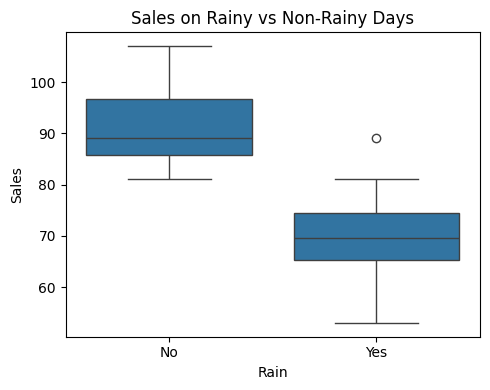

In [11]:
rain_summary = df.groupby("Rain")["Sales"].agg(["mean","count"])
print(rain_summary)

plt.figure(figsize=(5,4))
sns.boxplot(x="Rain", y="Sales", data=df)
plt.title("Sales on Rainy vs Non-Rainy Days")
plt.tight_layout()
plt.show()


## Conclusion: Linear or Non-linear?

- **Tourists vs Sales** → Pearson r = 0.93, Spearman rho close behind. Strong, clearly **linear** relationship — more tourists, more ice cream sold, in a fairly straight-line way.
- **Temperature vs Sales** → Pearson r = 0.86, also **linear** and strong. Hotter days drive more sales in a roughly proportional way.
- **Price vs Sales** → Pearson r = 0.09, essentially **no relationship** in this sample (likely because price only ranges $0.75-$2.00, too narrow a band, or demand isn't very price-sensitive here).
- **Rain** → non-rainy days average ~$92k in sales vs ~$70k on rainy days, so rain has a real negative effect on sales — but since it's categorical (Yes/No), this is best captured as a group difference rather than a linear correlation with a numeric slope.

**Overall:** Sales is best explained by a linear combination of Temperature and Tourists (both close to 1:1 with the regression line), while Price adds little linear signal on its own — a multiple linear regression using Temperature + Tourists (and possibly Rain as a binary flag) would likely fit this data well.